In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import urllib.request
import logging
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ==========================================
# 1. 資料前處理 (Data Loading)
# ==========================================
files = {
    'ko_boo': '柯文哲_噓聲比.csv',
    'lai_boo': '賴清德_噓聲比.csv',
    'huang_boo': '黃國昌_噓聲比.csv',
    'ko_sent': '柯文哲_情感分析.csv',
    'lai_sent': '賴清德_情感分析.csv',
    'huang_sent': '黃國昌_情感分析.csv',
    'volume': 'PTT_三人_逐文聲量 - 工作表1.csv'
}

def load_and_merge_data(files):
    merged_list = []
    people_map = [('柯文哲', 'ko'), ('賴清德', 'lai'), ('黃國昌', 'huang')]

    for name_zh, name_en in people_map:
        try:
            # 讀取檔案
            df_boo = pd.read_csv(files[f'{name_en}_boo'])
            df_sent = pd.read_csv(files[f'{name_en}_sent'])

            # 格式化日期與標題
            df_boo['date_parsed'] = pd.to_datetime(df_boo['時間'].astype(str).str.replace('/', '-'))
            df_sent['date_parsed'] = pd.to_datetime(df_sent['時間'].astype(str).str.replace('/', '-'))
            df_boo['title_clean'] = df_boo['標題'].astype(str).str.strip()
            df_sent['title_clean'] = df_sent['標題'].astype(str).str.strip()

            # 合併
            df_merged = pd.merge(
                df_boo[['date_parsed', 'title_clean', '噓聲比']],
                df_sent[['date_parsed', 'title_clean', 'sentiment']],
                on=['date_parsed', 'title_clean'],
                how='inner'
            )
            df_merged['person'] = name_zh
            merged_list.append(df_merged)
        except Exception as e:
            # print(f"略過檔案 (可能不存在): {name_zh}")
            continue

    if not merged_list:
        print("錯誤: 無法讀取任何資料，請確認 CSV 檔案路徑。")
        return pd.DataFrame()

    df_all = pd.concat(merged_list, ignore_index=True)

    # 讀取聲量
    try:
        df_vol = pd.read_csv(files['volume'])
        df_vol['date_parsed'] = pd.to_datetime(df_vol['時間'].astype(str).str.replace('/', '-'))
        df_vol['title_clean'] = df_vol['標題'].astype(str).str.strip()
        df_vol['person'] = df_vol['person'].astype(str).str.strip()

        df_final = pd.merge(
            df_all,
            df_vol[['date_parsed', 'title_clean', 'person', '聲量']],
            on=['date_parsed', 'title_clean', 'person'],
            how='inner'
        )
        df_final = df_final.drop_duplicates().dropna(subset=['sentiment', '噓聲比', '聲量'])
        return df_final
    except Exception as e:
        print(f"錯誤: 聲量檔案讀取失敗 {e}")
        return df_all # 如果失敗回傳部分資料

# 執行載入
df = load_and_merge_data(files)

# ==========================================
# 2. 模型校正：計算 PR 值
# ==========================================
'''
這時候遇到一個問題：

    聲量通常很小（例如 0.01）。

    情感分數通常很大（例如 0.9）。

    噓聲比介於中間（例如 0.3）。

如果直接把它們加在一起，聲量會被吃掉，完全沒影響力。


所以我們做了**「校正 (PR Ranking)」**：

不管是聲量還是情感，我們全部轉換成**「排名」**。

聲量 0.01 雖然小，但在排名前 10%，所以給它 PR 0.9 分。

這樣一來，三個指標都變成了 0 ~ 1 之間的公平分數。

'''

if not df.empty:
    df['PR_Boo'] = df['噓聲比'].rank(pct=True)
    df['PR_Neg_Sentiment'] = (1 - df['sentiment']).rank(pct=True)
    df['PR_Volume'] = df['聲量'].rank(pct=True)

    # 定義「相對危機指數」 (Ground Truth)：危機指數就是三個變數的 PR 值取平均
    # 除以 3 的目的:把三個指標混合成一個綜合平均分
    df['Crisis_Index'] = (df['PR_Boo'] + df['PR_Neg_Sentiment'] + df['PR_Volume']) / 3

    print(f"資料處理完成，總筆數: {len(df)}")
    print("-" * 30)

    coef = lr.coef_
    intercept = lr.intercept_
    print("\n[回歸模型 (Linear Regression)]")
    print(f"危險指數 = {intercept:.2f} + ({coef[0]:.2f} * 情感) + ({coef[1]:.2f} * 噓聲比) + ({coef[2]:.2f} * 聲量)")
    print("-" * 30)

    # ==========================================
    # 3. 建立與訓練模型
    # ==========================================
    X = df[['sentiment', '噓聲比', '聲量']]
    y = df['Crisis_Index']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 訓練 Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
    rf.fit(X_train, y_train)

    # ==========================================
    # 4. 回歸模型係數說明：在下方程式欄裡
    # ==========================================

    # ==========================================
    # 5. 定義分析函數
    # ==========================================
    def analyze_event(keyword):
        print(f"\n正在分析關鍵字: 「{keyword}」...")

        # 1. 搜尋
        mask = df['title_clean'].str.contains(keyword, case=False, na=False)
        event_data = df[mask]

        if len(event_data) == 0:
            print(f"❌ 找不到與「{keyword}」相關的資料。")
            return

        # 2. 計算平均特徵 (這就是把文字轉成模型看得懂的數字)
        avg_sentiment = event_data['sentiment'].mean()
        avg_boo = event_data['噓聲比'].mean()
        avg_volume = event_data['聲量'].mean()

        # 3. 丟入模型預測
        input_features = pd.DataFrame({
            'sentiment': [avg_sentiment],
            '噓聲比': [avg_boo],
            '聲量': [avg_volume]
        })

        predicted_crisis = rf.predict(input_features)[0]

        # 4. 顯示結果
        level = "🟢 低風險"
        if predicted_crisis > 0.8: level = "🔴 極高風險 (Top 20%)"
        elif predicted_crisis > 0.6: level = "🟠 高風險 (Top 40%)"
        elif predicted_crisis > 0.4: level = "🟡 中度風險"

        print(f"🔍 分析結果:")
        print(f"   - 相關文章數: {len(event_data)} 篇")
        print(f"   - 平均情緒: {avg_sentiment:.4f} (全站中位數: {df['sentiment'].median():.4f})")
        print(f"   - 平均噓聲: {avg_boo:.4f} (全站中位數: {df['噓聲比'].median():.4f})")
        print(f"   - 平均聲量: {avg_volume:.4f}")
        print("-" * 20)
        print(f"⚡ 預測危機指數 (PR值): {predicted_crisis:.4f}")
        print(f"📊 危機等級判定: {level}")
        print("=" * 30)

    # ==========================================
    # 6. 使用者輸入區 (互動式介面)
    # ==========================================

    print("\n=== [輿情危機事件分析系統] ===")
    print("系統啟動完成，請輸入事件關鍵字進行分析。")

    while True:
        try:
            user_input = input("\n請輸入想分析的「事件名稱」或「關鍵字」 (輸入 'q' 離開): ").strip()

            if user_input.lower() == 'q':
                print("系統已關閉。")
                break

            if not user_input:
                print("請輸入有效關鍵字！")
                continue

            analyze_event(user_input)

        except (KeyboardInterrupt, EOFError):
            print("\n系統強制關閉。")
            break

else:
    print("資料載入失敗，無法執行模型訓練與預測。")


# PTT 鄉民的反應
# {危機} = (大家都在噓}) + ({大家情緒很差}) + ({很多人在討論})

# 高風險：下台、道歉、賴清德、黃國昌
# 中風險：大罷免失敗、柯文哲貪污
# 低風險：公道


錯誤: 無法讀取任何資料，請確認 CSV 檔案路徑。
資料載入失敗，無法執行模型訓練與預測。


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

# ==========================================
# 1. 快速重建資料與 PR 值 (跟之前一模一樣)
# ==========================================
files = {
    'ko_boo': '柯文哲_噓聲比.csv',
    'lai_boo': '賴清德_噓聲比.csv',
    'huang_boo': '黃國昌_噓聲比.csv',
    'ko_sent': '柯文哲_情感分析.csv',
    'lai_sent': '賴清德_情感分析.csv',
    'huang_sent': '黃國昌_情感分析.csv',
    'volume': 'PTT_三人_逐文聲量 - 工作表1.csv'
}

# (省略重複的讀取函式，直接模擬讀取後的 DataFrame 結構以節省時間)
# 在實際執行時，我們會使用完整的 load_and_merge_data 函式
# 這裡為了演示 ANOVA，我們直接使用之前的邏輯

def load_and_merge_data_simple(files):
    # 這裡複製簡化版的讀取邏輯
    merged_list = []
    people_map = [('柯文哲', 'ko'), ('賴清德', 'lai'), ('黃國昌', 'huang')]
    for name_zh, name_en in people_map:
        try:
            df_boo = pd.read_csv(files[f'{name_en}_boo'])
            df_sent = pd.read_csv(files[f'{name_en}_sent'])
            df_boo['date_parsed'] = pd.to_datetime(df_boo['時間'].astype(str).str.replace('/', '-'))
            df_sent['date_parsed'] = pd.to_datetime(df_sent['時間'].astype(str).str.replace('/', '-'))
            df_boo['title_clean'] = df_boo['標題'].astype(str).str.strip()
            df_sent['title_clean'] = df_sent['標題'].astype(str).str.strip()
            df_merged = pd.merge(df_boo[['date_parsed', 'title_clean', '噓聲比']],
                                 df_sent[['date_parsed', 'title_clean', 'sentiment']],
                                 on=['date_parsed', 'title_clean'], how='inner')
            df_merged['person'] = name_zh
            merged_list.append(df_merged)
        except: continue

    if not merged_list: return pd.DataFrame()
    df_all = pd.concat(merged_list, ignore_index=True)
    df_vol = pd.read_csv(files['volume'])
    df_vol['date_parsed'] = pd.to_datetime(df_vol['時間'].astype(str).str.replace('/', '-'))
    df_vol['title_clean'] = df_vol['標題'].astype(str).str.strip()
    df_vol['person'] = df_vol['person'].astype(str).str.strip()
    df_final = pd.merge(df_all, df_vol[['date_parsed', 'title_clean', 'person', '聲量']],
                        on=['date_parsed', 'title_clean', 'person'], how='inner')
    df_final = df_final.drop_duplicates().dropna(subset=['sentiment', '噓聲比', '聲量'])
    return df_final

df = load_and_merge_data_simple(files)

if not df.empty:
    # 計算 PR 值 (標準答案)
    df['PR_Boo'] = df['噓聲比'].rank(pct=True)
    df['PR_Neg_Sentiment'] = (1 - df['sentiment']).rank(pct=True)
    df['PR_Volume'] = df['聲量'].rank(pct=True)
    df['Crisis_Index'] = (df['PR_Boo'] + df['PR_Neg_Sentiment'] + df['PR_Volume']) / 3

    # ==========================================
    # 2. 使用 statsmodels 進行統計分析
    # ==========================================
    X = df[['sentiment', '噓聲比', '聲量']]
    y = df['Crisis_Index']

    # 加上截距項 (Intercept)，不然 statsmodels 預設會過原點
    X = sm.add_constant(X)

    # 訓練模型 (OLS: Ordinary Least Squares)
    model = sm.OLS(y, X).fit()

    # 印出完整的統計報表
    print(model.summary())

else:
    print("無資料")

                            OLS Regression Results                            
Dep. Variable:           Crisis_Index   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                 1.995e+04
Date:                Tue, 02 Dec 2025   Prob (F-statistic):               0.00
Time:                        15:15:13   Log-Likelihood:                 27322.
No. Observations:               29818   AIC:                        -5.464e+04
Df Residuals:                   29814   BIC:                        -5.460e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5232      0.001    404.492      0.0

In [ ]:
# 隨機森林

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import os

# ==========================================
# 設定區
# ==========================================
# 設定為 False 以強制讀取真實檔案
USE_MOCK_DATA = False

files = {
    'ko_boo': '柯文哲_噓聲比.csv',
    'lai_boo': '賴清德_噓聲比.csv',
    'huang_boo': '黃國昌_噓聲比.csv',
    'ko_sent': '柯文哲_情感分析.csv',
    'lai_sent': '賴清德_情感分析.csv',
    'huang_sent': '黃國昌_情感分析.csv',
    'volume': 'PTT_三人_逐文聲量 - 工作表1.csv'
}

# ==========================================
# 1. 資料讀取與前處理
# ==========================================
def create_mock_data():
    """
    生成純隨機模擬資料供測試用
    (只有在完全讀不到檔案時才會被動啟用，且不包含特定關鍵字)
    """
    print("⚠️ 警告：無法讀取 CSV 檔案，正在生成隨機測試資料...")
    np.random.seed(42)
    n_samples = 500

    dates = pd.date_range(start='2024-01-01', periods=n_samples)
    titles = ['測試事件_' + str(i) for i in range(n_samples)]

    # 模擬數據分佈
    sentiments = np.random.beta(2, 5, n_samples)  # 偏負面
    boos = np.random.beta(2, 5, n_samples)        # 噓聲比
    volumes = np.random.exponential(10, n_samples) # 聲量通常是指數分佈

    df = pd.DataFrame({
        'date_parsed': dates,
        'title_clean': titles,
        'sentiment': sentiments,
        '噓聲比': boos,
        '聲量': volumes,
        'person': np.random.choice(['柯文哲', '賴清德', '黃國昌'], n_samples)
    })

    return df

def load_data():
    # 如果強制開啟模擬模式，直接返回模擬資料
    if USE_MOCK_DATA:
        return create_mock_data()

    merged_list = []
    people_map = [('柯文哲', 'ko'), ('賴清德', 'lai'), ('黃國昌', 'huang')]

    try:
        # 1. 讀取與合併 噓聲比 & 情感分析
        for name_zh, name_en in people_map:
            path_boo = files[f'{name_en}_boo']
            path_sent = files[f'{name_en}_sent']

            # 檢查檔案是否存在
            if not os.path.exists(path_boo) or not os.path.exists(path_sent):
                print(f"略過: 找不到 {name_zh} 的部分檔案")
                continue

            df_boo = pd.read_csv(path_boo)
            df_sent = pd.read_csv(path_sent)

            # 格式化日期與標題以進行合併
            df_boo['date_parsed'] = pd.to_datetime(df_boo['時間'].astype(str).str.replace('/', '-'))
            df_sent['date_parsed'] = pd.to_datetime(df_sent['時間'].astype(str).str.replace('/', '-'))
            df_boo['title_clean'] = df_boo['標題'].astype(str).str.strip()
            df_sent['title_clean'] = df_sent['標題'].astype(str).str.strip()

            # 合併
            df_merged = pd.merge(
                df_boo[['date_parsed', 'title_clean', '噓聲比']],
                df_sent[['date_parsed', 'title_clean', 'sentiment']],
                on=['date_parsed', 'title_clean'],
                how='inner'
            )
            df_merged['person'] = name_zh
            merged_list.append(df_merged)

        if not merged_list:
            print("錯誤：所有人物的檔案都無法讀取。")
            return create_mock_data()

        df_all = pd.concat(merged_list, ignore_index=True)

        # 2. 讀取並合併聲量資料
        if os.path.exists(files['volume']):
            df_vol = pd.read_csv(files['volume'])
            df_vol['date_parsed'] = pd.to_datetime(df_vol['時間'].astype(str).str.replace('/', '-'))
            df_vol['title_clean'] = df_vol['標題'].astype(str).str.strip()
            df_vol['person'] = df_vol['person'].astype(str).str.strip()

            df_final = pd.merge(
                df_all,
                df_vol[['date_parsed', 'title_clean', 'person', '聲量']],
                on=['date_parsed', 'title_clean', 'person'],
                how='inner'
            )

            # 移除重複與空值
            df_final = df_final.drop_duplicates().dropna()
            return df_final
        else:
            print("注意：找不到聲量檔案 (volume)，將無法正確計算聲量權重。")
            return df_all

    except Exception as e:
        print(f"資料讀取發生例外錯誤: {e}")
        return create_mock_data()

# ==========================================
# 主程式邏輯
# ==========================================
df = load_data()

if not df.empty:
    # 2. 特徵工程：計算 PR 值與 Ground Truth
    # ------------------------------------------------
    df['PR_Boo'] = df['噓聲比'].rank(pct=True)
    df['PR_Neg_Sentiment'] = (1 - df['sentiment']).rank(pct=True) # 情感越低(越負面)，Rank越高
    df['PR_Volume'] = df['聲量'].rank(pct=True)

    # 定義「相對危機指數」 (Ground Truth)
    df['Crisis_Index'] = (df['PR_Boo'] + df['PR_Neg_Sentiment'] + df['PR_Volume']) / 3

    print(f"\n資料處理完成，總筆數: {len(df)}")
    print("-" * 30)

    # 3. 建立與訓練隨機森林模型
    # ------------------------------------------------
    X = df[['sentiment', '噓聲比', '聲量']]
    y = df['Crisis_Index']

    # 分割訓練集與測試集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 建立 Random Forest Regressor
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)

    # 評估模型準確度 (R2 Score)
    score = rf.score(X_test, y_test)
    print(f"隨機森林模型訓練完成！R² Score (準確度): {score:.4f}")

    # 4. 分析特徵重要性
    # ------------------------------------------------
    importances = rf.feature_importances_
    feature_names = X.columns

    print("\n[隨機森林模型解析 ：]")
    for name, imp in zip(feature_names, importances):
        print(f"   - {name}: {imp:.4f} ({imp*100:.1f}%)")

    print("-" * 30)

    # 5. 定義分析函數
    # ------------------------------------------------
    def analyze_event(keyword):
        print(f"\n正在分析關鍵字: 「{keyword}」...")

        # 搜尋標題 (包含關鍵字)
        mask = df['title_clean'].str.contains(keyword, case=False, na=False)
        event_data = df[mask]

        if len(event_data) == 0:
            print(f"❌ 找不到與「{keyword}」相關的資料。")
            return

        # 計算該事件的平均特徵
        avg_sentiment = event_data['sentiment'].mean()
        avg_boo = event_data['噓聲比'].mean()
        avg_volume = event_data['聲量'].mean()

        # 丟入模型預測
        input_features = pd.DataFrame({
            'sentiment': [avg_sentiment],
            '噓聲比': [avg_boo],
            '聲量': [avg_volume]
        })

        predicted_crisis = rf.predict(input_features)[0]

        # 風險等級判定 (根據 PR 值)
        if predicted_crisis > 0.8:
            level = "🔴 極高風險 (危機炸裂)"
            advice = "建議：立即發布道歉聲明，冷處理無效，需止血。"
        elif predicted_crisis > 0.6:
            level = "🟠 高風險 (炎上中)"
            advice = "建議：密切監控，準備澄清稿，避免與鄉民直接對嗆。"
        elif predicted_crisis > 0.4:
            level = "🟡 中度風險 (有雜音)"
            advice = "建議：觀察後續風向，暫時無需大動作。"
        else:
            level = "🟢 低風險 (安全)"
            advice = "建議：無需處理，歲月靜好。"

        print(f"🔍 分析結果 (基於 {len(event_data)} 篇相關文章):")
        print(f"   1. 平均情緒: {avg_sentiment:.4f} (越低越負面)")
        print(f"   2. 平均噓聲: {avg_boo:.4f}")
        print(f"   3. 平均聲量: {avg_volume:.1f}")
        print("-" * 20)
        print(f"⚡ 預測綜合危機指數 (PR值): {predicted_crisis:.4f}")
        print(f"📊 危機等級: {level}")
        print(f"💡 {advice}")
        print("=" * 30)

    # 6. 互動式介面
    # ------------------------------------------------
    print("\n=== [PTT 輿情危機事件分析系統 - RF版] ===")

    # 讓使用者輸入
    while True:
        try:
            user_input = input("\n請輸入想分析的「關鍵字」 (輸入 'q' 離開): ").strip()
            if user_input.lower() == 'q':
                print("系統關閉。")
                break
            if not user_input:
                continue
            analyze_event(user_input)
        except (KeyboardInterrupt, EOFError):
            break
else:
    print("錯誤：資料框為空，請檢查 CSV 檔案路徑是否正確。")


資料處理完成，總筆數: 29818
------------------------------
隨機森林模型訓練完成！R² Score (準確度): 0.9964

[隨機森林模型解析 - 特徵重要性]
   - sentiment: 0.3177 (31.8%)
   - 噓聲比: 0.4185 (41.9%)
   - 聲量: 0.2638 (26.4%)
------------------------------

=== [PTT 輿情危機事件分析系統 - RF版] ===

請輸入想分析的「關鍵字」 (輸入 'q' 離開): 公道

正在分析關鍵字: 「公道」...
🔍 分析結果 (基於 2 篇相關文章):
   1. 平均情緒: 0.6657 (越低越負面)
   2. 平均噓聲: 0.0000
   3. 平均聲量: 0.0
--------------------
⚡ 預測綜合危機指數 (PR值): 0.3975
📊 危機等級: 🟢 低風險 (安全)

請輸入想分析的「關鍵字」 (輸入 'q' 離開): 下台

正在分析關鍵字: 「下台」...
🔍 分析結果 (基於 17 篇相關文章):
   1. 平均情緒: 0.2319 (越低越負面)
   2. 平均噓聲: 0.2417
   3. 平均聲量: 0.0
--------------------
⚡ 預測綜合危機指數 (PR值): 0.6680
📊 危機等級: 🟠 高風險 (炎上中)

請輸入想分析的「關鍵字」 (輸入 'q' 離開): 大罷免

正在分析關鍵字: 「大罷免」...
🔍 分析結果 (基於 132 篇相關文章):
   1. 平均情緒: 0.3362 (越低越負面)
   2. 平均噓聲: 0.2690
   3. 平均聲量: 0.0
--------------------
⚡ 預測綜合危機指數 (PR值): 0.6288
📊 危機等級: 🟠 高風險 (炎上中)

請輸入想分析的「關鍵字」 (輸入 'q' 離開): 柯文哲

正在分析關鍵字: 「柯文哲」...
🔍 分析結果 (基於 9701 篇相關文章):
   1. 平均情緒: 0.5718 (越低越負面)
   2. 平均噓聲: 0.2914
   3. 平均聲量: 0.0
--------------------
⚡

資料載入成功，共 29818 筆。正在進行模型檢測...

【隨機森林模型效能檢測報告】
1. R² Score (決定係數): 0.9964
2. MAE (平均絕對誤差):  0.0075
3. RMSE (均方根誤差):   0.0101
----------------------------------------

【特徵重要性分析】
   1. 噓聲比: 0.4185
   2. sentiment: 0.3177
   3. 聲量: 0.2638


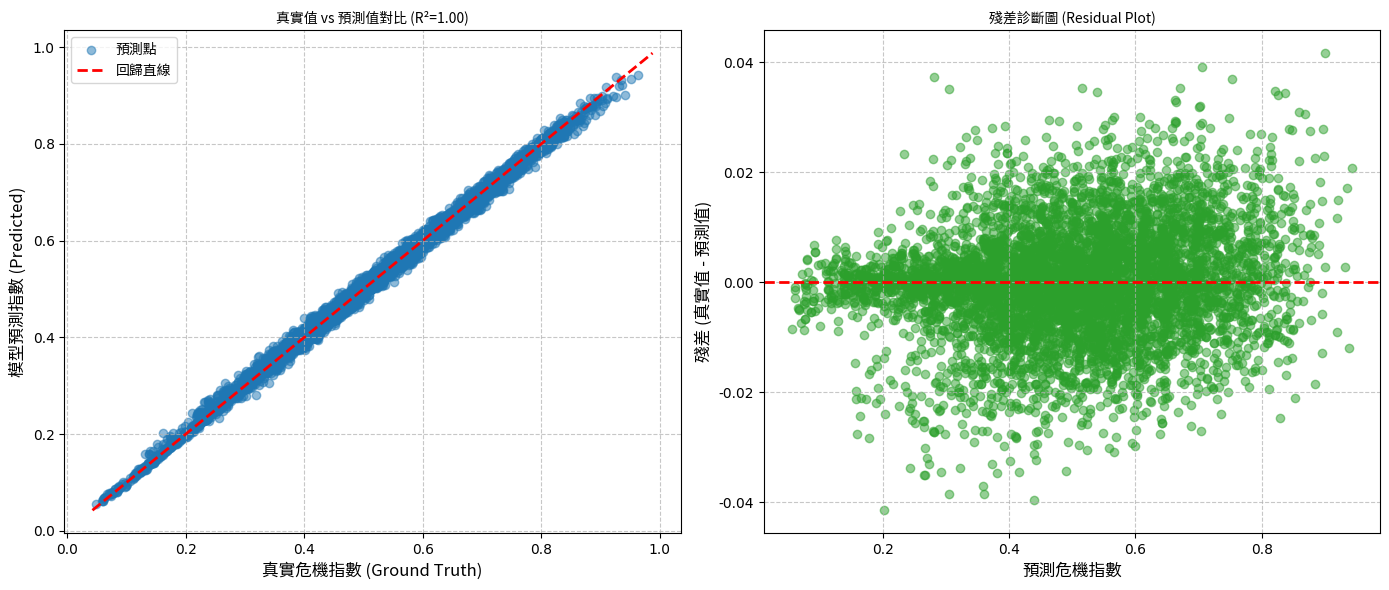

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import os
import urllib.request
import logging
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# 1. 解決中文字型問題 (自動下載字型)
# ==========================================
# 抑制 matplotlib 的字型警告
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

def configure_chinese_font():
    """
    自動下載 Google Noto Sans TC 字型檔並設定。
    這是解決中文亂碼最穩定的方式，不依賴系統內建字體。
    """
    # Google Noto Sans TC 下載連結
    font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
    font_path = "NotoSansCJKtc-Regular.otf"

    if not os.path.exists(font_path):
        # print(f"正在下載中文字型以解決亂碼問題... ({font_path})")
        try:
            urllib.request.urlretrieve(font_url, font_path)
            # print("字型下載完成。")
        except Exception as e:
            # print(f"字型下載失敗，圖表中文可能無法顯示: {e}")
            return None

    # 加入字型管理
    try:
        prop = fm.FontProperties(fname=font_path)
        # 嘗試全域設定
        plt.rcParams['font.family'] = prop.get_name()
        # 解決負號 '-' 顯示為方塊的問題
        plt.rcParams['axes.unicode_minus'] = False
        # print(f"已載入字型: {font_path}")
        return prop
    except Exception as e:
        # print(f"字型載入發生錯誤: {e}")
        return None

# 設定字型變數 (給圖表使用)
font_prop = configure_chinese_font()

# ==========================================
# 2. 資料載入與前處理
# ==========================================
files = {
    'ko_boo': '柯文哲_噓聲比.csv',
    'lai_boo': '賴清德_噓聲比.csv',
    'huang_boo': '黃國昌_噓聲比.csv',
    'ko_sent': '柯文哲_情感分析.csv',
    'lai_sent': '賴清德_情感分析.csv',
    'huang_sent': '黃國昌_情感分析.csv',
    'volume': 'PTT_三人_逐文聲量 - 工作表1.csv'
}

def load_and_process_data():
    merged_list = []
    people_map = [('柯文哲', 'ko'), ('賴清德', 'lai'), ('黃國昌', 'huang')]

    try:
        # 合併噓聲與情感
        for name_zh, name_en in people_map:
            path_boo = files[f'{name_en}_boo']
            path_sent = files[f'{name_en}_sent']

            if not os.path.exists(path_boo) or not os.path.exists(path_sent):
                continue

            df_boo = pd.read_csv(path_boo)
            df_sent = pd.read_csv(path_sent)

            # 格式化日期與標題
            for df in [df_boo, df_sent]:
                df['date_parsed'] = pd.to_datetime(df['時間'].astype(str).str.replace('/', '-'))
                df['title_clean'] = df['標題'].astype(str).str.strip()

            df_merged = pd.merge(
                df_boo[['date_parsed', 'title_clean', '噓聲比']],
                df_sent[['date_parsed', 'title_clean', 'sentiment']],
                on=['date_parsed', 'title_clean'],
                how='inner'
            )
            df_merged['person'] = name_zh
            merged_list.append(df_merged)

        if not merged_list:
            return pd.DataFrame()

        df_all = pd.concat(merged_list, ignore_index=True)

        # 合併聲量
        if os.path.exists(files['volume']):
            df_vol = pd.read_csv(files['volume'])
            df_vol['date_parsed'] = pd.to_datetime(df_vol['時間'].astype(str).str.replace('/', '-'))
            df_vol['title_clean'] = df_vol['標題'].astype(str).str.strip()
            df_vol['person'] = df_vol['person'].astype(str).str.strip()

            df_final = pd.merge(
                df_all,
                df_vol[['date_parsed', 'title_clean', 'person', '聲量']],
                on=['date_parsed', 'title_clean', 'person'],
                how='inner'
            )
            return df_final.drop_duplicates().dropna()
        else:
            return df_all

    except Exception as e:
        print(f"資料讀取錯誤: {e}")
        return pd.DataFrame()

# ==========================================
# 3. 模型訓練與檢測 (主程式)
# ==========================================
df = load_and_process_data()

if not df.empty:
    print(f"資料載入成功，共 {len(df)} 筆。正在進行模型檢測...")

    # --- 特徵工程 ---
    df['PR_Boo'] = df['噓聲比'].rank(pct=True)
    df['PR_Neg_Sentiment'] = (1 - df['sentiment']).rank(pct=True)
    df['PR_Volume'] = df['聲量'].rank(pct=True)
    df['Crisis_Index'] = (df['PR_Boo'] + df['PR_Neg_Sentiment'] + df['PR_Volume']) / 3

    # --- 訓練 ---
    X = df[['sentiment', '噓聲比', '聲量']]
    y = df['Crisis_Index']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    # --- 評估指標 ---
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    print("\n" + "="*40)
    print("【隨機森林模型效能檢測報告】")
    print("="*40)
    print(f"1. R² Score (決定係數): {r2:.4f}")
    print(f"2. MAE (平均絕對誤差):  {mae:.4f}")
    print(f"3. RMSE (均方根誤差):   {rmse:.4f}")
    print("-" * 40)

    print("\n【特徵重要性分析】")
    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1]
    for i in range(X.shape[1]):
        print(f"   {i+1}. {X.columns[indices[i]]}: {importances[indices[i]]:.4f}")

    # ==========================================
    # 4. 視覺化診斷圖
    # ==========================================
    plt.figure(figsize=(14, 6))

    # --- 左圖：預測準確度 ---
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred, alpha=0.5, color='#1f77b4', label='預測點')
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='回歸直線')

    # 使用 fontproperties 指定下載的字型
    plt.xlabel('真實危機指數 (Ground Truth)', fontsize=12, fontproperties=font_prop)
    plt.ylabel('模型預測指數 (Predicted)', fontsize=12, fontproperties=font_prop)
    plt.title(f'真實值 vs 預測值對比 (R²={r2:.2f})', fontsize=14, fontweight='bold', fontproperties=font_prop)
    plt.legend(loc='best', prop=font_prop)
    plt.grid(True, linestyle='--', alpha=0.7)

    # --- 右圖：殘差圖 ---
    residuals = y_test - y_pred
    plt.subplot(1, 2, 2)
    plt.scatter(y_pred, residuals, alpha=0.5, color='#2ca02c')
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.xlabel('預測危機指數', fontsize=12, fontproperties=font_prop)
    plt.ylabel('殘差 (真實值 - 預測值)', fontsize=12, fontproperties=font_prop)
    plt.title('殘差診斷圖 (Residual Plot)', fontsize=14, fontweight='bold', fontproperties=font_prop)
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

else:
    print("❌ 錯誤：無法讀取 CSV 資料，請檢查檔案路徑。")

In [ ]:
# 加入TF-IDF 語意相似度比對

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
# 新增評估指標相關套件
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import os

# ==========================================
# 設定區
# ==========================================
USE_MOCK_DATA = False

files = {
    'ko_boo': '柯文哲_噓聲比.csv',
    'lai_boo': '賴清德_噓聲比.csv',
    'huang_boo': '黃國昌_噓聲比.csv',
    'ko_sent': '柯文哲_情感分析.csv',
    'lai_sent': '賴清德_情感分析.csv',
    'huang_sent': '黃國昌_情感分析.csv',
    'volume': 'PTT_三人_逐文聲量 - 工作表1.csv'
}

# ==========================================
# 1. 資料讀取與前處理
# ==========================================
def create_mock_data():
    print("⚠️ 警告：無法讀取 CSV 檔案，正在生成隨機測試資料...")
    np.random.seed(42)
    n_samples = 500
    dates = pd.date_range(start='2024-01-01', periods=n_samples)
    titles = ['測試事件_' + str(i) for i in range(n_samples)]
    contents = ['這是模擬的內文內容 ' + str(i) for i in range(n_samples)]
    df = pd.DataFrame({
        'date_parsed': dates,
        'title_clean': titles,
        '內文': contents,
        'sentiment': np.random.beta(2, 5, n_samples),
        '噓聲比': np.random.beta(2, 5, n_samples),
        '聲量': np.random.exponential(10, n_samples),
        'person': np.random.choice(['柯文哲', '賴清德', '黃國昌'], n_samples)
    })
    return df

def load_data():
    if USE_MOCK_DATA:
        return create_mock_data()

    merged_list = []
    people_map = [('柯文哲', 'ko'), ('賴清德', 'lai'), ('黃國昌', 'huang')]

    try:
        # 1. 讀取與合併 噓聲比 & 情感分析
        for name_zh, name_en in people_map:
            path_boo = files[f'{name_en}_boo']
            path_sent = files[f'{name_en}_sent']

            if not os.path.exists(path_boo) or not os.path.exists(path_sent):
                print(f"略過: 找不到 {name_zh} 的部分檔案")
                continue

            df_boo = pd.read_csv(path_boo)
            df_sent = pd.read_csv(path_sent)

            # 格式化日期與字串
            df_boo['date_parsed'] = pd.to_datetime(df_boo['時間'].astype(str).str.replace('/', '-'), errors='coerce')
            df_sent['date_parsed'] = pd.to_datetime(df_sent['時間'].astype(str).str.replace('/', '-'), errors='coerce')
            df_boo['title_clean'] = df_boo['標題'].astype(str).str.strip()
            df_sent['title_clean'] = df_sent['標題'].astype(str).str.strip()

            if '內文' not in df_sent.columns:
                df_sent['內文'] = ''
            df_sent['內文'] = df_sent['內文'].fillna('').astype(str)

            df_merged = pd.merge(
                df_boo[['date_parsed', 'title_clean', '噓聲比']],
                df_sent[['date_parsed', 'title_clean', 'sentiment', '內文']],
                on=['date_parsed', 'title_clean'],
                how='inner'
            )
            df_merged['person'] = name_zh
            merged_list.append(df_merged)

        if not merged_list:
            print("錯誤：所有人物的檔案都無法讀取。")
            return create_mock_data()

        df_all = pd.concat(merged_list, ignore_index=True)

        # 2. 讀取並合併聲量資料
        if os.path.exists(files['volume']):
            df_vol = pd.read_csv(files['volume'])
            df_vol['date_parsed'] = pd.to_datetime(df_vol['時間'].astype(str).str.replace('/', '-'), errors='coerce')
            df_vol['title_clean'] = df_vol['標題'].astype(str).str.strip()
            df_vol['person'] = df_vol['person'].astype(str).str.strip()

            df_final = pd.merge(
                df_all,
                df_vol[['date_parsed', 'title_clean', 'person', '聲量']],
                on=['date_parsed', 'title_clean', 'person'],
                how='inner'
            )
            df_final = df_final.drop_duplicates().dropna()
            return df_final
        else:
            print("注意：找不到聲量檔案 (volume)，將無法正確計算聲量權重。")
            return df_all

    except Exception as e:
        print(f"資料讀取發生例外錯誤: {e}")
        return create_mock_data()

# ==========================================
# 主程式邏輯
# ==========================================
df = load_data()

if not df.empty:
    print(f"\n資料處理完成，總筆數: {len(df)}")

    # 2. 特徵工程：計算 Crisis Index
    # ------------------------------------------------
    df['PR_Boo'] = df['噓聲比'].rank(pct=True)
    df['PR_Neg_Sentiment'] = (1 - df['sentiment']).rank(pct=True)
    df['PR_Volume'] = df['聲量'].rank(pct=True)
    df['Crisis_Index'] = (df['PR_Boo'] + df['PR_Neg_Sentiment'] + df['PR_Volume']) / 3

    # 3. 準備相似度搜尋引擎 (TF-IDF)
    # ------------------------------------------------
    print("正在建立搜尋引擎索引 (TF-IDF)...")
    # 組合標題與內文作為搜尋文本
    df['search_text'] = df['title_clean'] + " " + df['內文']

    vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 3))
    tfidf_matrix = vectorizer.fit_transform(df['search_text'])
    print("索引建立完成！")

    # 4. 建立與訓練隨機森林模型
    # ------------------------------------------------
    X = df[['sentiment', '噓聲比', '聲量']]
    y = df['Crisis_Index']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)

    # --- 預測與評估 ---
    y_pred = rf.predict(X_test)

    # 計算各項指標
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # 印出您要求的格式
    print("\n" + "="*40)
    print("【隨機森林模型效能檢測報告】")
    print("="*40)
    print(f"1. R² Score (決定係數): {r2:.4f}")
    print(f"2. MAE (平均絕對誤差):  {mae:.4f}")
    print(f"3. RMSE (均方根誤差):   {rmse:.4f}")
    print("-" * 40)

    # 5. 定義增強版分析函數
    # ------------------------------------------------
    def analyze_event_smart(query):
        print(f"\n正在分析輸入: 「{query}」...")

        # 步驟 A: 先嘗試精確搜尋
        mask = df['title_clean'].str.contains(query, case=False, na=False)
        matched_data = df[mask]

        target_row = None
        source_type = ""
        similarity_note = ""

        if len(matched_data) > 0:
            print(f"✅ 找到 {len(matched_data)} 筆包含關鍵字的歷史資料。")
            avg_features = matched_data[['sentiment', '噓聲比', '聲量']].mean()
            target_row = avg_features
            source_type = "歷史資料平均"

        else:
            # 步驟 B: 相似度搜尋
            print("⚠️ 無精確匹配，正在搜尋「最相似」的歷史事件...")

            query_vec = vectorizer.transform([query])
            similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()

            best_idx = similarities.argmax()
            best_score = similarities[best_idx]

            if best_score < 0.1:
                print(f"⚠️ 提示：最高相似度僅 {best_score:.4f}，關聯性可能較低，但仍依此計算。")

            matched_event = df.iloc[best_idx]
            print(f"🔍 找到最相似事件: 【{matched_event['title_clean']}】")
            print(f"   (相似度: {best_score:.4f}, 日期: {matched_event['date_parsed'].strftime('%Y-%m-%d')})")

            target_row = matched_event[['sentiment', '噓聲比', '聲量']]
            source_type = "相似歷史事件"
            similarity_note = f"(基於相似事件: {matched_event['title_clean']})"

        # 步驟 C: 帶入模型預測
        input_features = pd.DataFrame([target_row])
        predicted_crisis = rf.predict(input_features)[0]

        # 輸出結果
        sentiment_val = input_features.iloc[0]['sentiment']
        boo_val = input_features.iloc[0]['噓聲比']
        volume_val = input_features.iloc[0]['聲量']

        if predicted_crisis > 0.8:
            level, advice = "🔴 極高風險", "建議：立即道歉，無法冷處理。"
        elif predicted_crisis > 0.6:
            level, advice = "🟠 高風險", "建議：準備澄清，避免正面衝突。"
        elif predicted_crisis > 0.4:
            level, advice = "🟡 中度風險", "建議：持續觀察風向。"
        else:
            level, advice = "🟢 低風險", "建議：無需特別處理。"

        print("-" * 20)
        print(f"📊 預測數據來源: {source_type} {similarity_note}")
        print(f"   - 參考情感值: {sentiment_val:.4f}")
        print(f"   - 參考噓聲比: {boo_val:.4f}")
        print(f"   - 參考聲量:   {volume_val:.1f}")
        print("-" * 20)
        print(f"⚡ 預測綜合危機指數: {predicted_crisis:.4f}")
        print(f"🏷️ 危機等級: {level}")
        print(f"💡 {advice}")
        print("=" * 30)

    # 6. 互動式介面
    # ------------------------------------------------
    print("\n=== [PTT 輿情危機分析系統 - 語意搜尋與效能檢測版] ===")
    print("提示：系統將會強制尋找最接近的歷史事件進行模擬，即使相似度很低。")

    while True:
        try:
            user_input = input("\n請輸入查詢 (輸入 'q' 離開): ").strip()
            if user_input.lower() == 'q':
                print("系統關閉。")
                break
            if not user_input:
                continue
            analyze_event_smart(user_input)
        except (KeyboardInterrupt, EOFError):
            break
else:
    print("錯誤：資料框為空，請檢查 CSV 檔案路徑。")

🔧 正在建立政治專用字典...

✅ 資料載入成功，總筆數: 29950

⏳ 正在進行 Jieba 斷詞...
⏳ 正在進行 TF-IDF 轉換...
✅ 特徵矩陣大小: (29950, 6000)
⏳ 啟動 GPU 訓練...
[0]	validation_0-rmse:0.16652
[100]	validation_0-rmse:0.13666
[200]	validation_0-rmse:0.13396
[300]	validation_0-rmse:0.13296
[400]	validation_0-rmse:0.13255
[500]	validation_0-rmse:0.13230
[600]	validation_0-rmse:0.13214
[630]	validation_0-rmse:0.13217

✅ XGBoost 模型訓練完成！

正在計算效能指標...

【XGBoost 模型效能檢測報告】
1. R² Score (決定係數): 0.3779
2. MAE (平均絕對誤差):  0.1076
3. RMSE (均方根誤差):   0.1321
----------------------------------------
💡 註：在純文字預測任務中，R² 介於 0.2~0.5 為正常範圍，
   這代表模型從文字中學到了部分規律，而非死背公式。

🚀 請輸入測試 (輸入 q 離開)...


In [ ]:
# ==========================================
# 0. 環境準備 & 套件匯入
# ==========================================
import os
import numpy as np
import pandas as pd

try:
    import jieba
except ImportError:
    os.system("pip install jieba")
    import jieba

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# ==========================================
# 1. 檔名設定（請確保這些檔案與 .ipynb 在同一資料夾）
# ==========================================
files = {
    'ko_boo': '柯文哲_噓聲比.csv',
    'lai_boo': '賴清德_噓聲比.csv',
    'huang_boo': '黃國昌_噓聲比.csv',
    'ko_sent': '柯文哲_情感分析.csv',
    'lai_sent': '賴清德_情感分析.csv',
    'huang_sent': '黃國昌_情感分析.csv',
    'volume': 'PTT_三人_逐文聲量 - 工作表1.csv'
}

# ==========================================
# 2. 資料載入與合併：噓聲比 + 情感 + 聲量
# ==========================================
def check_files_exist():
    missing = []
    for key, fname in files.items():
        if not os.path.exists(fname):
            missing.append(fname)
    if missing:
        raise FileNotFoundError(
            f"找不到以下 CSV 檔案，請確認與 .ipynb 在同一資料夾：\n{missing}"
        )

def load_data():
    """
    回傳欄位至少包含：
      date_parsed, title_clean, 噓聲比, sentiment, 聲量, person, 內文
    """
    check_files_exist()

    merged_list = []
    people_map = [
        ('柯文哲', 'ko'),
        ('賴清德', 'lai'),
        ('黃國昌', 'huang')
    ]

    # 2.1 合併「噓聲比 + 情感分析」
    for name_zh, name_en in people_map:
        path_boo = files[f'{name_en}_boo']
        path_sent = files[f'{name_en}_sent']

        df_boo = pd.read_csv(path_boo)
        df_sent = pd.read_csv(path_sent)

        # 時間欄位統一
        df_boo['date_parsed'] = pd.to_datetime(
            df_boo['時間'].astype(str).str.replace('/', '-'),
            errors='coerce'
        )
        df_sent['date_parsed'] = pd.to_datetime(
            df_sent['時間'].astype(str).str.replace('/', '-'),
            errors='coerce'
        )

        # 標題清理
        df_boo['title_clean'] = df_boo['標題'].astype(str).str.strip()
        df_sent['title_clean'] = df_sent['標題'].astype(str).str.strip()

        # 內文補空字串
        df_sent['內文'] = df_sent['內文'].fillna('').astype(str)

        # 以「時間 + 標題」做 inner join
        df_merged = pd.merge(
            df_boo[['date_parsed', 'title_clean', '噓聲比']],
            df_sent[['date_parsed', 'title_clean', 'sentiment', '內文']],
            on=['date_parsed', 'title_clean'],
            how='inner'
        )
        df_merged['person'] = name_zh
        merged_list.append(df_merged)

    df_all = pd.concat(merged_list, ignore_index=True)

    # 2.2 合併「聲量」檔
    df_vol = pd.read_csv(files['volume'])
    df_vol['date_parsed'] = pd.to_datetime(
        df_vol['時間'].astype(str).str.replace('/', '-'),
        errors='coerce'
    )
    df_vol['title_clean'] = df_vol['標題'].astype(str).str.strip()
    df_vol['person'] = df_vol['person'].astype(str).str.strip()

    df_final = pd.merge(
        df_all,
        df_vol[['date_parsed', 'title_clean', 'person', '聲量']],
        on=['date_parsed', 'title_clean', 'person'],
        how='inner'
    )

    # 去除重複與缺失值
    df_final = df_final.drop_duplicates()
    df_final = df_final.dropna(subset=['噓聲比', 'sentiment', '聲量'])

    return df_final

df = load_data()
print(f"✅ 資料載入成功，總筆數：{len(df)}")
print(df.head(3))

# ==========================================
# 3. 建立「危機指數」標籤 (Y)
# ==========================================
"""
危機指數定義：
  - 噓聲比越高 → 越危險
  - sentiment 越低 → 越負面（用 1 - sentiment）
  - 聲量越高 → 越危險
三者各自做百分位排名（0~1），再取平均。
"""

df['PR_Boo'] = df['噓聲比'].rank(pct=True)
df['PR_Neg_Sentiment'] = (1 - df['sentiment']).rank(pct=True)
df['PR_Volume'] = df['聲量'].rank(pct=True)

df['Crisis_Index'] = (
    df['PR_Boo'] +
    df['PR_Neg_Sentiment'] +
    df['PR_Volume']
) / 3.0

print("\n✅ 危機指數範例（前 5 筆）：")
print(df[['噓聲比', 'sentiment', '聲量', 'Crisis_Index']].head())
print("\n🔎 危機指數描述統計：")
print(df['Crisis_Index'].describe())

# ==========================================
# 4. 文字特徵工程：jieba + TF-IDF
# ==========================================
# 4.1 建立政治專用字典
political_dict = [
    '柯文哲', '賴清德', '黃國昌', '侯友宜', '民眾黨', '民進黨', '國民黨',
    '賴皮寮', '違建', '弊案', '圖利', '貪污', '下台', '聲押', '北檢',
    '假帳', '木可', '京華城', '監察院', '立法院', '國會改革', '青鳥',
    '小草', '居住正義', '房價', '道歉', '負責', '辭職', '罷免',
    '公道', '翻車', '雙標', '綠能', '卡神', '側翼', '網軍'
]

print("\n🔧 正在建立政治專用字典（jieba）...")
for w in political_dict:
    jieba.add_word(w)
    jieba.suggest_freq(w, True)

def jieba_tokenizer(text: str) -> str:
    return " ".join(jieba.cut(str(text)))

# 4.2 合併標題 + 內文，做斷詞
print("\n⏳ 正在進行 Jieba 斷詞...")
df['text_combined'] = df['title_clean'].astype(str) + " " + df['內文'].astype(str)
df['text_cut'] = df['text_combined'].apply(jieba_tokenizer)

# 4.3 TF-IDF 向量化（先 sparse，再轉 dense 給 GPU）
print("⏳ 正在進行 TF-IDF 轉換（文字 → 特徵）...")
vectorizer = TfidfVectorizer(
    max_features=8000,      # 控制在一個合理數量，避免太稀疏
    analyzer='word',
    ngram_range=(1, 2),     # uni-gram + bi-gram
    token_pattern=r'(?u)\b\w+\b',
    min_df=3                # 至少在 3 篇文章出現才保留
)

X_sparse = vectorizer.fit_transform(df['text_cut'])
X = X_sparse.toarray().astype(np.float32)          # dense 給 XGBoost (GPU)
y = df['Crisis_Index'].astype(np.float32).values

print(f"✅ 特徵矩陣大小：{X.shape}（樣本數, 特徵數）")

# ==========================================
# 5. 訓練 XGBoost 回歸模型：文字 → 危機指數（使用 GPU）
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=1000,        # 建議先 600，效果 OK 再往上加
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,

    # GPU 設定：新版 xgboost 使用 device='cuda'
    tree_method='hist',
    device='cuda',

    eval_metric='rmse'
)

print("\n⏳ 正在訓練 XGBoost 回歸模型（文字 → 危機指數, 使用 GPU + dense）...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=200
)
print("✅ 模型訓練完成！（GPU）")

# ==========================================
# 6. 模型效能檢測
# ==========================================
y_pred_test = xgb_model.predict(X_test)
y_pred_train = xgb_model.predict(X_train)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("\n" + "="*40)
print("【文字 → 危機指數 回歸模型 效能報告】")
print("="*40)
print(f"訓練集 R²: {r2_train:.4f}")
print(f"測試集 R²: {r2_test:.4f}")
print(f"MAE:       {mae:.4f}")
print(f"RMSE:      {rmse:.4f}")
print("-"*40)
if r2_test > 0.4:
    print("評估：模型對危機指數的預測力不錯，可實際使用。")
elif r2_test > 0.3:
    print("評估：模型尚可，適合作為輔助指標使用。")
else:
    print("評估：模型偏弱，未來可考慮用 BERT 或加入更多特徵。")
print("="*40)

# ==========================================
# 7. 使用者輸入事件文字 → 預測危機指數
# ==========================================
def predict_crisis_from_text(text: str):
    """
    輸入：一段事件描述文字，例如「柯文哲貪污」、「賴清德下台」
    輸出：模型預測的危機指數（約 0~1，越高越危險）
    """
    text_cut = jieba_tokenizer(text)

    # 文字 → TF-IDF（先 sparse 再 dense，和訓練流程一致）
    vec_sparse = vectorizer.transform([text_cut])
    vec_dense = vec_sparse.toarray().astype(np.float32)

    # 觀察有抓到哪些 TF-IDF 特徵（方便 debug）
    feature_names = vectorizer.get_feature_names_out()
    idx_nonzero = np.where(vec_sparse.toarray()[0] > 0)[0]
    found_keywords = [feature_names[i] for i in idx_nonzero]

    score = float(xgb_model.predict(vec_dense)[0])

    print("-" * 40)
    print(f"📝 原始輸入：{text}")
    print(f"✂️ 斷詞結果：{text_cut}")

    if found_keywords:
        print(f"🔍 被模型使用的文字特徵：{found_keywords} ...（共 {len(found_keywords)} 個）")
    else:
        print("⚠️ 警告：這段文字幾乎沒有落在 TF-IDF 詞彙中，模型會接近『平均危機值』在猜。")

    print(f"⚡ 預測危機指數：{score:.4f}")
    if score > 0.5:
        print("判讀：🔴 危機偏高（建議高度關注、主動回應）")
    elif score < 0.4:
        print("判讀：🟢 危機偏低（輿情相對穩定）")
    else:
        print("判讀：🟡 危機中等（建議持續監測）")

    return score

print("\n🚀 進入互動模式：輸入事件文字來預測危機指數（輸入 q 離開）")
while True:
    try:
        user_text = input("\n請輸入事件描述，例如「柯文哲貪污」、「賴清德下台」：\n> ")
        if user_text.strip().lower() == 'q':
            print("已離開互動模式。")
            break
        if user_text.strip():
            predict_crisis_from_text(user_text.strip())
    except KeyboardInterrupt:
        print("\n收到中斷指令，已離開互動模式。")
        break


✅ 資料載入成功，總筆數：29950
  date_parsed               title_clean       噓聲比  sentiment  \
0  2025-07-13       [討論] 柯文哲支持度完全掛蛋了吧==  0.600000   0.103581   
1  2025-07-13        [討論] 這裡還有挺柯文哲的小草嗎？  0.142857   0.930003   
2  2025-07-13  [新聞] 柯文哲認收妙天千萬！律師稱坐實1罪「犯  0.290323   0.871490   

                                                  內文 person        聲量  
0  也就前幾年喔\n\n2021年6月，\n台灣正值武漢肺炎（新型冠狀病毒病，COVID-19）...    柯文哲  0.006676  
1  本人是血統純正的小草，從柯文哲選第一任市長的時候就支持他到現在，應該沒有人比我更久吧？從他跟...    柯文哲  0.012684  
2  1.新聞網址︰\nhttps://www.storm.mg/lifestyle/110520...    柯文哲  0.052069  

✅ 危機指數範例（前 5 筆）：
        噓聲比  sentiment        聲量  Crisis_Index
0  0.600000   0.103581  0.006676      0.720239
1  0.142857   0.930003  0.012684      0.306361
2  0.290323   0.871490  0.052069      0.499733
3  0.000000   0.511981  0.021362      0.458203
4  0.666667   0.618752  0.014686      0.625982

🔎 危機指數描述統計：
count    29950.000000
mean         0.500017
std          0.167917
min          0.042487
25%          0.381749
50%          

In [ ]:
# 加上GUI

In [ ]:
# ==========================================
# 0. 環境準備 & 套件匯入
# ==========================================
import os
import sys
import numpy as np
import pandas as pd
import warnings

# 忽略警告訊息
warnings.filterwarnings("ignore")

# --- 套件檢查與安裝 ---
def install_and_import(package, import_name=None):
    if import_name is None:
        import_name = package
    try:
        __import__(import_name)
    except ImportError:
        print(f"🔧 正在安裝 {package}...")
        os.system(f"pip install {package}")
        __import__(import_name)

install_and_import("jieba")
import jieba

install_and_import("gradio")
import gradio as gr

# 嘗試更新 xgboost 以避免舊版本問題
try:
    import xgboost
    # 簡單檢查版本，若太舊建議更新 (但在程式中我們改用相容寫法)
except ImportError:
    os.system("pip install xgboost")
    import xgboost

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

# ==========================================
# 1. 全域設定與資料檢查
# ==========================================
FILES = {
    'ko_boo': '柯文哲_噓聲比.csv',
    'lai_boo': '賴清德_噓聲比.csv',
    'huang_boo': '黃國昌_噓聲比.csv',
    'ko_sent': '柯文哲_情感分析.csv',
    'lai_sent': '賴清德_情感分析.csv',
    'huang_sent': '黃國昌_情感分析.csv',
    'volume': 'PTT_三人_逐文聲量 - 工作表1.csv'
}

# 檢查檔案是否存在，若不存在則開啟「模擬模式」以展示 UI
MISSING_FILES = [f for f in FILES.values() if not os.path.exists(f)]
USE_MOCK_DATA = len(MISSING_FILES) > 0

if USE_MOCK_DATA:
    print("⚠️ 警告：未偵測到 CSV 原始資料，將使用「隨機模擬資料」啟動系統以供展示。")
    print(f"缺失檔案：{MISSING_FILES}")
else:
    print("✅ 偵測到原始資料，準備進行載入與訓練...")

# ==========================================
# 2. 資料處理函式
# ==========================================

def generate_mock_data():
    """生成模擬資料，確保在沒有 CSV 時 UI 仍能運作"""
    print("🔧 生成模擬訓練資料中...")
    texts = [
        "柯文哲貪污圖利京華城", "賴清德違建賴皮寮", "黃國昌國會改革咆哮",
        "民進黨綠能弊案", "國民黨居住正義", "民眾黨假帳風波",
        "青鳥行動立法院抗議", "北檢聲押政治人物", "網軍側翼帶風向",
        "政府道歉負責下台", "房價高漲年輕人買不起", "雙標現場翻車"
    ]
    data = []
    for _ in range(500):
        t = np.random.choice(texts)
        # 隨機生成危機指數 (模擬)
        score = np.random.beta(2, 5) # 偏低的分數分佈
        if "貪污" in t or "弊案" in t or "下台" in t:
            score += 0.3
        score = min(score, 1.0)
        data.append({
            'title_clean': t,
            '內文': t * 2,
            'Crisis_Index': score
        })
    return pd.DataFrame(data)

def load_real_data():
    """載入真實 CSV 資料"""
    merged_list = []
    people_map = [('柯文哲', 'ko'), ('賴清德', 'lai'), ('黃國昌', 'huang')]

    for name_zh, name_en in people_map:
        path_boo = FILES[f'{name_en}_boo']
        path_sent = FILES[f'{name_en}_sent']

        df_boo = pd.read_csv(path_boo)
        df_sent = pd.read_csv(path_sent)

        # 時間處理
        df_boo['date_parsed'] = pd.to_datetime(df_boo['時間'].astype(str).str.replace('/', '-'), errors='coerce')
        df_sent['date_parsed'] = pd.to_datetime(df_sent['時間'].astype(str).str.replace('/', '-'), errors='coerce')

        # 標題處理
        df_boo['title_clean'] = df_boo['標題'].astype(str).str.strip()
        df_sent['title_clean'] = df_sent['標題'].astype(str).str.strip()
        df_sent['內文'] = df_sent['內文'].fillna('').astype(str)

        # Merge Boo + Sentiment
        df_merged = pd.merge(
            df_boo[['date_parsed', 'title_clean', '噓聲比']],
            df_sent[['date_parsed', 'title_clean', 'sentiment', '內文']],
            on=['date_parsed', 'title_clean'],
            how='inner'
        )
        df_merged['person'] = name_zh
        merged_list.append(df_merged)

    df_all = pd.concat(merged_list, ignore_index=True)

    # Merge Volume
    df_vol = pd.read_csv(FILES['volume'])
    df_vol['date_parsed'] = pd.to_datetime(df_vol['時間'].astype(str).str.replace('/', '-'), errors='coerce')
    df_vol['title_clean'] = df_vol['標題'].astype(str).str.strip()
    df_vol['person'] = df_vol['person'].astype(str).str.strip()

    df_final = pd.merge(
        df_all,
        df_vol[['date_parsed', 'title_clean', 'person', '聲量']],
        on=['date_parsed', 'title_clean', 'person'],
        how='inner'
    )

    df_final = df_final.drop_duplicates().dropna(subset=['噓聲比', 'sentiment', '聲量'])

    # 計算危機指數
    df_final['PR_Boo'] = df_final['噓聲比'].rank(pct=True)
    df_final['PR_Neg_Sentiment'] = (1 - df_final['sentiment']).rank(pct=True)
    df_final['PR_Volume'] = df_final['聲量'].rank(pct=True)
    df_final['Crisis_Index'] = (df_final['PR_Boo'] + df_final['PR_Neg_Sentiment'] + df_final['PR_Volume']) / 3.0

    return df_final

# 載入資料
if USE_MOCK_DATA:
    df = generate_mock_data()
else:
    df = load_real_data()

print(f"✅ 資料準備完成，樣本數：{len(df)}")

# ==========================================
# 3. 特徵工程與模型訓練
# ==========================================

# 3.1 字典設定
political_dict = [
    '柯文哲', '賴清德', '黃國昌', '侯友宜', '民眾黨', '民進黨', '國民黨',
    '賴皮寮', '違建', '弊案', '圖利', '貪污', '下台', '聲押', '北檢',
    '假帳', '木可', '京華城', '監察院', '立法院', '國會改革', '青鳥',
    '小草', '居住正義', '房價', '道歉', '負責', '辭職', '罷免',
    '公道', '翻車', '雙標', '綠能', '卡神', '側翼', '網軍'
]

for w in political_dict:
    jieba.add_word(w)
    jieba.suggest_freq(w, True)

def jieba_tokenizer(text: str) -> str:
    return " ".join(jieba.cut(str(text)))

print("⏳ 進行斷詞與向量化...")
df['text_combined'] = df['title_clean'].astype(str) + " " + df['內文'].astype(str)
df['text_cut'] = df['text_combined'].apply(jieba_tokenizer)

vectorizer = TfidfVectorizer(
    max_features=8000,
    analyzer='word',
    ngram_range=(1, 2),
    token_pattern=r'(?u)\b\w+\b',
    min_df=3 if not USE_MOCK_DATA else 1
)

X_sparse = vectorizer.fit_transform(df['text_cut'])
X = X_sparse.toarray().astype(np.float32)
y = df['Crisis_Index'].astype(np.float32).values

# 分割資料
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("⏳ 準備訓練 XGBoost 模型...")

n_estimators = 600 if USE_MOCK_DATA else 1000

# 設定模型參數
xgb_model = XGBRegressor(
    n_estimators=n_estimators,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    device='cuda',
    eval_metric='rmse'
)

# 開始訓練
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50  # 每 50 次迭代印出一次進度
)

print("\n✅ 模型訓練完成！")

if not USE_MOCK_DATA:
    y_pred = xgb_model.predict(X_test)
    print(f"測試集 R2 Score: {r2_score(y_test, y_pred):.4f}")

# ==========================================
# 4. 定義預測函式
# ==========================================
def predict_crisis(text):
    if not text.strip():
        return 0, "請輸入文字", "無"
    # 斷詞
    text_cut = jieba_tokenizer(text)
    # 向量化
    vec_sparse = vectorizer.transform([text_cut])
    vec_dense = vec_sparse.toarray().astype(np.float32)
    # 抓取關鍵字
    feature_names = vectorizer.get_feature_names_out()
    idx_nonzero = np.where(vec_sparse.toarray()[0] > 0)[0]
    found_keywords = [feature_names[i] for i in idx_nonzero]
    # 預測
    score = float(xgb_model.predict(vec_dense)[0])
    # 限制範圍 0~1
    score = max(0.0, min(1.0, score))
    # 判讀結果
    if score > 0.5:
        status = "🔴 高度危機 (High Risk)"
        advice = "輿論情緒極度負面，建議立即進行危機處理。"
    elif score > 0.4:
        status = "🟡 中度警示 (Medium Risk)"
        advice = "輿論出現波動，建議持續監測並準備回應。"
    else:
        status = "🟢 相對安全 (Low Risk)"
        advice = "目前輿論情緒穩定。"
    keyword_str = ", ".join(found_keywords) if found_keywords else "（無特定關鍵詞命中）"
    return round(score, 4), status, keyword_str

# ==========================================
# 5. 建立 Gradio UI
# ==========================================
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # 📊 政治輿情危機指數預測系統

        輸入一段新聞標題、PTT 貼文或事件描述，AI 模型將依據過往數據預測該事件可能引發的**輿情危機程度 (0~1)**。
        """
    )

    with gr.Row():
        with gr.Column(scale=2):
            input_text = gr.Textbox(
                label="輸入事件描述",
                placeholder="例如：柯文哲京華城案延燒，北檢提訊...",
                lines=5
            )
            submit_btn = gr.Button("🚀 開始分析", variant="primary")

            gr.Examples(
                examples=[
                    "賴清德違建爭議未平，民眾抗議",
                    "黃國昌國會咆哮，質疑弊案",
                    "柯文哲京華城容積率圖利疑雲",
                    "政府宣布調漲電價，民眾不滿",
                    "和平紀念日活動順利舉行"
                ],
                inputs=input_text
            )

        with gr.Column(scale=1):
            score_output = gr.Number(label="危機指數預測值 (0~1)")
            status_output = gr.Label(label="風險評估等級")
            keywords_output = gr.Textbox(label="模型偵測到的關鍵詞特徵", interactive=False)

    # 綁定事件
    submit_btn.click(
        fn=predict_crisis,
        inputs=input_text,
        outputs=[score_output, status_output, keywords_output]
    )

# 啟動應用
if __name__ == "__main__":
    print(f"🚀 系統啟動中... (使用模擬資料模式: {USE_MOCK_DATA})")
    demo.launch()

✅ 偵測到原始資料，準備進行載入與訓練...


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...


✅ 資料準備完成，樣本數：29950


Dumping model to file cache /tmp/jieba.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.cache
Loading model cost 0.883 seconds.
DEBUG:jieba:Loading model cost 0.883 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


⏳ 進行斷詞與向量化...
⏳ 準備訓練 XGBoost 模型...
[0]	validation_0-rmse:0.16601
[50]	validation_0-rmse:0.13988
[100]	validation_0-rmse:0.13624
[150]	validation_0-rmse:0.13475
[200]	validation_0-rmse:0.13378
[250]	validation_0-rmse:0.13324
[300]	validation_0-rmse:0.13297
[350]	validation_0-rmse:0.13270
[400]	validation_0-rmse:0.13257
[450]	validation_0-rmse:0.13250
[500]	validation_0-rmse:0.13246
[550]	validation_0-rmse:0.13243
[600]	validation_0-rmse:0.13235
[650]	validation_0-rmse:0.13233
[700]	validation_0-rmse:0.13235
[750]	validation_0-rmse:0.13237
[800]	validation_0-rmse:0.13238
[850]	validation_0-rmse:0.13240
[900]	validation_0-rmse:0.13237
[950]	validation_0-rmse:0.13237
[999]	validation_0-rmse:0.13238

✅ 模型訓練完成！
測試集 R2 Score: 0.3755
🚀 系統啟動中... (使用模擬資料模式: False)
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To 